
 Fold 1/5

Epoch 1/60
85/85 ━━━━━━━━━━━━━━━━━━━━ 85s 654ms/step - accuracy: 0.8890 - loss: 0.3307 - val_accuracy: 0.4208 - val_loss: 1.1037 - learning_rate: 0.0010
Epoch 2/60
85/85 ━━━━━━━━━━━━━━━━━━━━ 75s 565ms/step - accuracy: 0.9506 - loss: 0.1145 - val_accuracy: 0.4292 - val_loss: 1.7254 - learning_rate: 0.0010
Epoch 3/60
85/85 ━━━━━━━━━━━━━━━━━━━━ 40s 467ms/step - accuracy: 0.9496 - loss: 0.1187 - val_accuracy: 0.5375 - val_loss: 1.5212 - learning_rate: 0.0010
Epoch 4/60
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.9676 - loss: 0.0688
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
85/85 ━━━━━━━━━━━━━━━━━━━━ 49s 570ms/step - accuracy: 0.9651 - loss: 0.0733 - val_accuracy: 0.7125 - val_loss: 1.2049 - learning_rate: 0.0010
Epoch 5/60
85/85 ━━━━━━━━━━━━━━━━━━━━ 39s 464ms/step - accuracy: 0.9713 - loss: 0.0687 - val_accuracy: 0.8479 - val_loss: 0.4979 - learning_rate: 5.0000e-04
Epoch 6/60
85/85 ━━━━━━━━━━━━━━━━━━━━ 35s 407ms/step - accuracy: 0.9

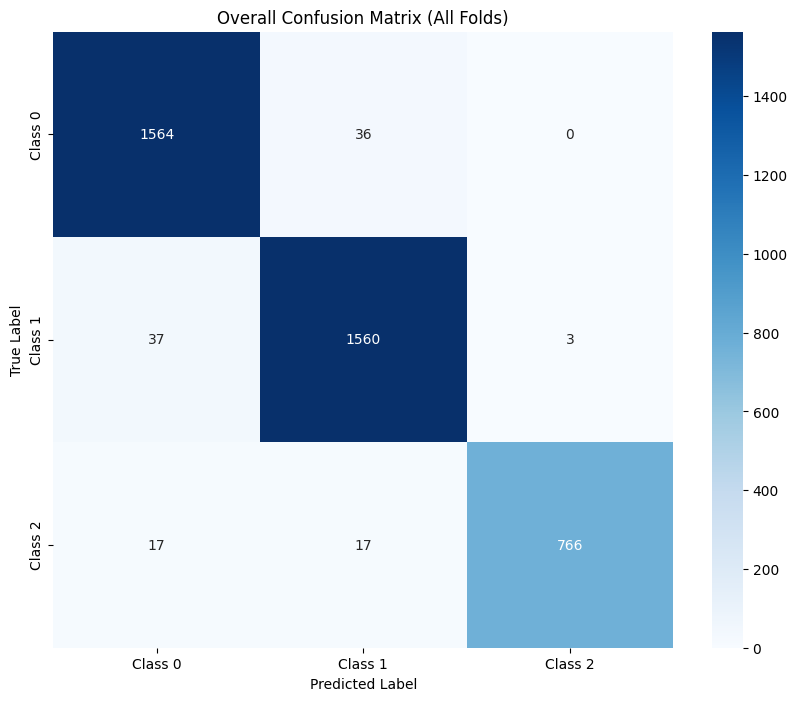


Aggregate Confusion Matrix Numerical Data:
[[1564   36    0]
 [  37 1560    3]
 [  17   17  766]]


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, LSTM, Dense, Dropout, 
                                     BatchNormalization, Bidirectional, Input, 
                                     Concatenate, Layer)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

PREPROCESSING_DIR = r"Preprocessing_Updated_Kfold"
N_FOLDS = 5
RESULTS_DIR = "results_3class_optimized"
NUM_CLASSES = 3
os.makedirs(RESULTS_DIR, exist_ok=True)

class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1),
                                 initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1),
                                 initializer="zeros")
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

def build_advanced_model(input_length, num_classes=3):
    input_layer = Input(shape=(input_length, 1))

    conv_a = Conv1D(32, kernel_size=3, padding='same', activation='relu')(input_layer)
    conv_b = Conv1D(32, kernel_size=7, padding='same', activation='relu')(input_layer)
    conv_c = Conv1D(32, kernel_size=11, padding='same', activation='relu')(input_layer)
    
    merged = Concatenate()([conv_a, conv_b, conv_c])
    x = BatchNormalization()(merged)
    x = MaxPooling1D(2)(x)
    x = Dropout(0.2)(x)

    x = Conv1D(128, kernel_size=5, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)
    
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    
    x = AttentionLayer()(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    output_layer = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def augment_signal(signal):
    noise = np.random.normal(0, 0.003, signal.shape)
    signal_noisy = signal + noise
    shift = np.random.randint(-10, 10)
    signal_shifted = np.roll(signal_noisy, shift)
    scale = np.random.uniform(0.9, 1.1)
    return signal_shifted * scale

def augment_batch(X, y):
    X_aug, y_aug = [], []
    for i in range(len(X)):
        X_aug.append(X[i])
        y_aug.append(y[i])
        X_aug.append(augment_signal(X[i]))
        y_aug.append(y[i])
    return np.array(X_aug), np.array(y_aug)

acc_per_fold = []
conf_matrices = []

for fold_no in range(N_FOLDS):
    print(f"\n Fold {fold_no + 1}/{N_FOLDS}")

    X_train_full = np.load(os.path.join(PREPROCESSING_DIR, f"fold_{fold_no}_X_train.npy"), allow_pickle=True)
    y_train_full = np.load(os.path.join(PREPROCESSING_DIR, f"fold_{fold_no}_y_train.npy"), allow_pickle=True)
    X_test = np.load(os.path.join(PREPROCESSING_DIR, f"fold_{fold_no}_X_test.npy"), allow_pickle=True)
    y_test = np.load(os.path.join(PREPROCESSING_DIR, f"fold_{fold_no}_y_test.npy"), allow_pickle=True)
    
    X_train_full = np.vstack(X_train_full).astype(np.float32) if X_train_full.dtype == object else X_train_full.astype(np.float32)
    X_test = np.vstack(X_test).astype(np.float32) if X_test.dtype == object else X_test.astype(np.float32)
    
    X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.15, stratify=y_train_full, random_state=42)

    X_train, y_train = augment_batch(X_train, y_train)

    X_train = X_train[..., np.newaxis]
    X_val = X_val[..., np.newaxis]
    X_test = X_test[..., np.newaxis]

    y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
    y_val_oh = tf.keras.utils.to_categorical(y_val, NUM_CLASSES)
    y_test_oh = tf.keras.utils.to_categorical(y_test, NUM_CLASSES)

    cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = dict(enumerate(cw))

    model = build_advanced_model(X_train.shape[1], NUM_CLASSES)
    
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train_oh,
        epochs=60,
        batch_size=64,
        validation_data=(X_val, y_val_oh),
        class_weight=class_weights,
        callbacks=[reduce_lr, early_stop],
        verbose=1
    )

    _, test_acc = model.evaluate(X_test, y_test_oh, verbose=0)
    acc_per_fold.append(test_acc)
    
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    cm = confusion_matrix(y_test, y_pred)
    conf_matrices.append(cm)

print("\n" + "="*30)
print(f" FINAL AVERAGE ACCURACY: {np.mean(acc_per_fold):.4f} =+ {np.std(acc_per_fold):.4f}")
print("="*30)

total_cm = np.sum(conf_matrices, axis=0)

plt.figure(figsize=(10, 8))
sns.heatmap(total_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Class {i}' for i in range(NUM_CLASSES)], 
            yticklabels=[f'Class {i}' for i in range(NUM_CLASSES)])
plt.title('Overall Confusion Matrix (All Folds)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig(os.path.join(RESULTS_DIR, 'aggregate_confusion_matrix.png'))
plt.show()

print("\nAggregate Confusion Matrix Numerical Data:")
print(total_cm)